# MultiConAD Data Analysis
Some useful visualization plots

## Extract Data and Create CSV

In [1]:
# import pandas as pd
# import json
# import os
# import librosa
# import soundfile as sf
# from pathlib import Path
# from joblib import Parallel, delayed


# # Read training data
# train_df = pd.read_json('../data/MultiConAD/train_English.jsonl', lines=True)
# train_df['split'] = 'train'

# # Read test data
# test_df = pd.read_json('../data/MultiConAD/test_English.jsonl', lines=True)
# test_df['split'] = 'test'

# # Combine into a single dataframe
# df = pd.concat([train_df, test_df], ignore_index=True)

# print(f"Combined dataframe shape: {df.shape}")
# print(f"Split distribution:\n{df['split'].value_counts()}")


# # Extract audio metadata from wav files
# audio_dir = '../data/MultiConAD'

# def extract_audio_metadata(audio_path):
#     """Extract metadata from an audio file"""
#     metadata = {
#         'duration': None,
#         'sampling_rate': None,
#         'n_samples': None,
#         'file_exists': False,
#         'file_size_mb': None
#     }
    
#     if not os.path.exists(audio_path):
#         print("Not found:", audio_path)
#         return metadata
    
#     metadata['file_exists'] = True
#     metadata['file_size_mb'] = os.path.getsize(audio_path) / (1024 * 1024)
    
#     try:
#         # Try with librosa first (works with mp3 and wav)
#         y, sr = librosa.load(audio_path, sr=None)
#         metadata['duration'] = librosa.get_duration(y=y, sr=sr)
#         metadata['sampling_rate'] = sr
#         metadata['n_samples'] = len(y)
#     except Exception as e:
#         print(f"Librosa error for {audio_path}: {e}")
#         # Fallback to soundfile for wav files
#         try:
#             data, sr = sf.read(audio_path)
#             metadata['sampling_rate'] = sr
#             metadata['n_samples'] = len(data)
#             metadata['duration'] = len(data) / sr
#         except Exception as e2:
#             print(f"Error reading {audio_path}: {e2}")
    
#     return metadata

# # Find audio filename in dataframe and extract metadata
# def get_audio_metadata_for_row(row):
#     """Get metadata for audio file referenced in a dataframe row"""
#     # Try different possible audio filename patterns
#     if 'Audio_file' in row and pd.notna(row['Audio_file']):
#         filename = row['Audio_file']
#         audio_path = os.path.join(audio_dir, filename)
#         if os.path.exists(audio_path):
#             print(f"Found: {audio_path}")
#             return extract_audio_metadata(audio_path)
#     return extract_audio_metadata('')  # Return empty metadata if not found

# print("Extracting audio metadata... This may take a few minutes")
# # Extract metadata for all entries
# metadata_list = []
# metadata_list = Parallel(n_jobs=-1)(
#     delayed(get_audio_metadata_for_row)(row) 
#     for idx, row in df.iterrows()
# )

# # Create metadata dataframe and merge with original dataframe
# metadata_df = pd.DataFrame(metadata_list)
# df = pd.concat([df, metadata_df], axis=1)

# del metadata_df

# print(f"\nAudio metadata extraction complete!")
# print(f"Audio files found: {df['file_exists'].sum()} / {len(df)}")

# df.to_csv('../data/MultiConAD/metadata.csv', index=False)

## Load CSV and Process

In [2]:
import pandas as pd
df=pd.read_csv('../data/MultiConAD/metadata.csv')

In [3]:
df.head()

,PID,Languages,MMSE,Diagnosis,Participants,Dataset,Modality,Task,File_ID,Media,...,Text_length,Audio_file,PT_file,Trillsson,split,duration,sampling_rate,n_samples,file_exists,file_size_mb
0,11312/a-00090661-0,eng,28,HC,"INV Investigator, PAR Participant",Pitt,audio,"['', 'Cookie']",034-1,audio,...,351,wav/Pitt_034-1.wav,pt_16k/Pitt_034-1.pt,trillsson/Pitt_034-1.pt,train,60.856485,44100,2683771,True,5.118929
1,11312/a-00094929-0,eng,Unknown,HC,"INV Investigator, PAR Participant",Delaware,audio,"['', 'Cookie', 'Cat', 'Rockwell', 'Cinderella_...",86-2,audio,...,3614,wav/Delaware_86-2.wav,pt_16k/Delaware_86-2.pt,trillsson/Delaware_86-2.pt,train,531.456000,48000,25509888,True,97.312542
2,11312/a-00088406-0,eng,Unknown,HC,"INV Investigator, PAR Participant",Delaware,audio,"['', 'Cookie', 'Cat', 'Rockwell', 'Cinderella_...",266-1,audio,...,4816,wav/Delaware_266-1.wav,pt_16k/Delaware_266-1.pt,trillsson/Delaware_266-1.pt,train,459.262656,32000,14696405,True,56.062378
3,11312/a-00090532-0,eng,18,Dementia,"INV Investigator, PAR Participant",Pitt,audio,"['', 'Cookie']",356-1,audio,...,489,wav/Pitt_356-1.wav,pt_16k/Pitt_356-1.pt,trillsson/Pitt_356-1.pt,train,39.547483,44100,1744044,True,3.326542
4,11312/a-00098652-0,eng,Unknown,HC,"INV Investigator, PAR Participant",Delaware,audio,"['', 'Cookie', 'Cat', 'Rockwell', 'Cinderella_...",357-1,audio,...,8759,wav/Delaware_357-1.wav,pt_16k/Delaware_357-1.pt,trillsson/Delaware_357-1.pt,train,740.904000,48000,35563392,True,135.663616


In [4]:
print(f"Combined dataframe shape: {df.shape}")
print(f"Total number of samples: {len(df)}")
print(f"Split distribution:\n{df['split'].value_counts()}")
print(f"Total Time: {df['duration'].sum() / 3600:.2f} hours")

Combined dataframe shape: (2469, 36)
Total number of samples: 2469
Split distribution:
split
train    2217
test      252
Name: count, dtype: int64
Total Time: 117.49 hours


### Various Sample Distributions

/tmp/ipykernel_578475/1330740522.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df[df['Dataset'] == dataset]['duration'].dropna() / 60 for dataset in datasets],


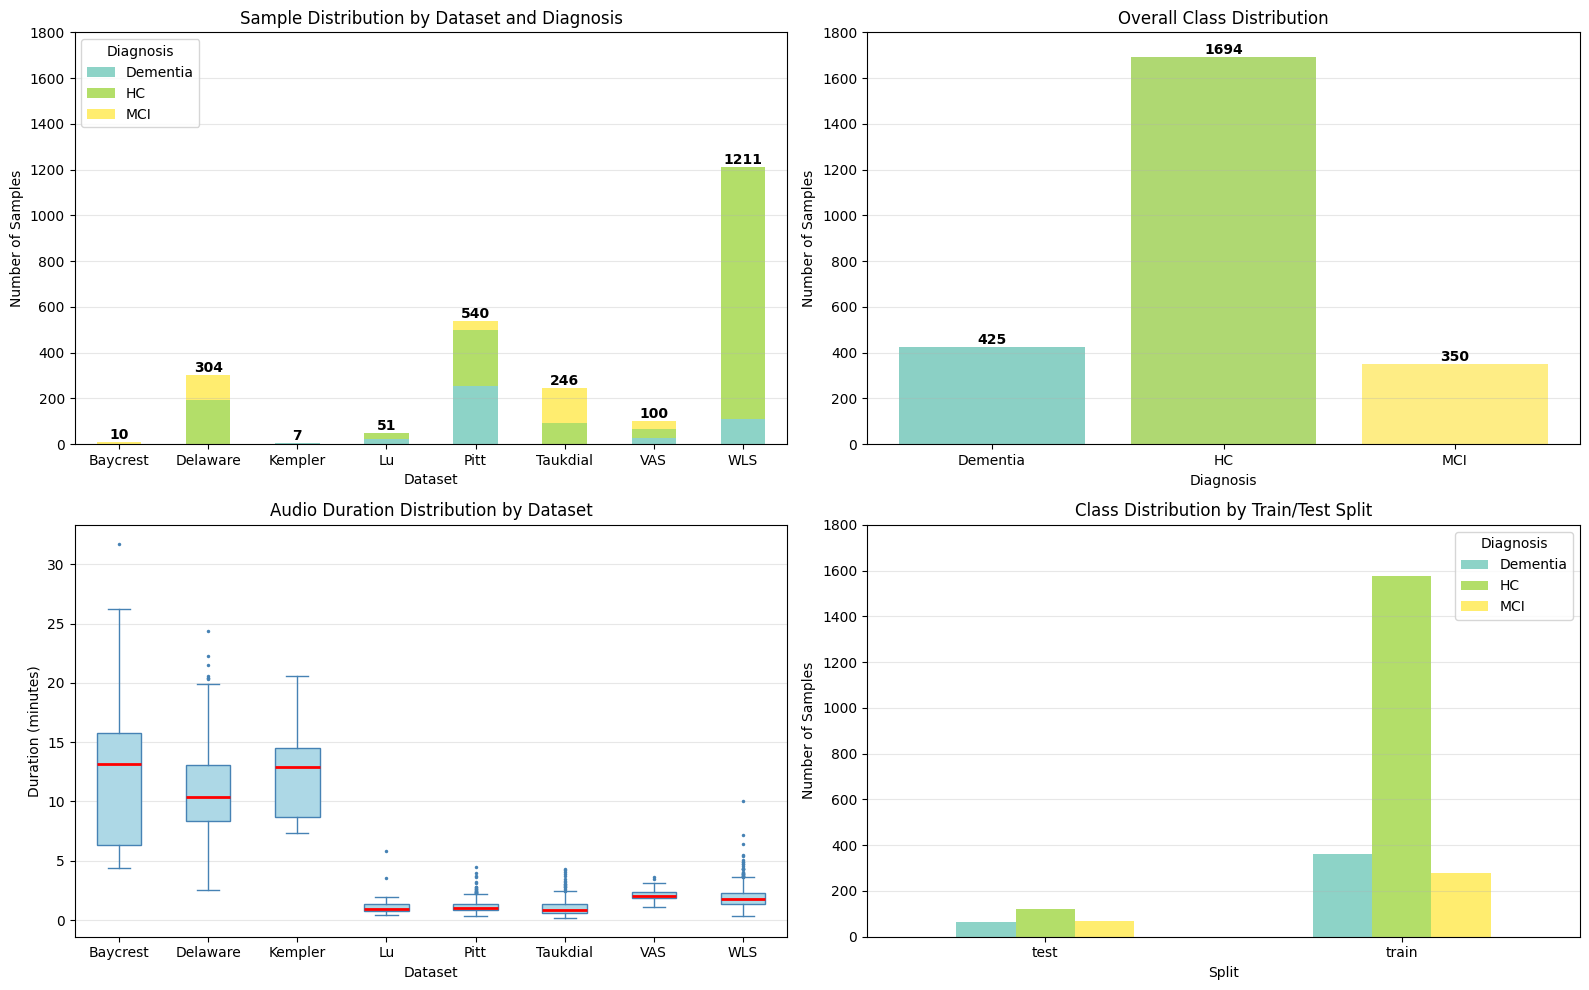

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

datasets=df['Dataset'].unique().tolist()
datasets.sort()
diagnosis_counts = df.groupby(['Dataset', 'Diagnosis']).size().unstack(fill_value=0)
diagnosis_dist = df['Diagnosis'].value_counts().sort_index()
split_diagnosis = df.groupby(['split', 'Diagnosis']).size().unstack(fill_value=0)

# Plot 1: Stacked bar plot of datasets by diagnosis
diagnosis_counts.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='Set3')
for i, (idx, row) in enumerate(diagnosis_counts.iterrows()):
    total = row.sum()
    axes[0, 0].text(i, total, str(int(total)), ha='center', va='bottom', fontweight='bold')
axes[0, 0].set_xlabel('Dataset')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_title('Sample Distribution by Dataset and Diagnosis')
axes[0, 0].legend(title='Diagnosis', loc='upper left')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0, ha='center')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim(0, 1800)

# Plot 2: Box plot of audio duration by dataset
axes[1, 0].boxplot([df[df['Dataset'] == dataset]['duration'].dropna() / 60 for dataset in datasets],
           labels=datasets,
           patch_artist=True,
           whis=1.5,
           showfliers=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'),
           flierprops=dict(marker='.', markerfacecolor='steelblue', markersize=5, linestyle='none', markeredgecolor='none'))
axes[1, 0].set_xlabel('Dataset')
axes[1, 0].set_ylabel('Duration (minutes)')
axes[1, 0].set_title('Audio Duration Distribution by Dataset')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 3: Overall diagnosis distribution
axes[0, 1].bar(diagnosis_dist.index, diagnosis_dist.values, color=['#8bd0c5', '#afd872', '#feed85'])
axes[0, 1].set_xlabel('Diagnosis')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_title('Overall Class Distribution')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(diagnosis_dist.values):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
axes[0, 1].set_ylim(0, 1800)

# Plot 4: Class distribution by split
split_diagnosis.plot(kind='bar', ax=axes[1, 1], colormap='Set3')
axes[1, 1].set_xlabel('Split')
axes[1, 1].set_ylabel('Number of Samples')
axes[1, 1].set_title('Class Distribution by Train/Test Split')
axes[1, 1].legend(title='Diagnosis')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim(0, 1800)

plt.tight_layout()
plt.savefig('../proposal/dataset.png')
plt.show()


### Distinct Speakers

In [6]:
distinct_pids = df['PID'].nunique()
print(f"Number of distinct PIDs: {distinct_pids}/{len(df)}")

pid_dataset = df.groupby('PID')['Dataset'].apply(lambda x: ', '.join(x.unique())).reset_index()
pid_dataset.columns = ['PID', 'Datasets']
pid_dataset['num_datasets'] = pid_dataset['Datasets'].str.split(', ').str.len()
pid_dataset['num_samples'] = df.groupby('PID').size().values
print(pid_dataset[pid_dataset['num_datasets'] > 1])
distinct_pids = df['PID'].nunique()
print(f"Number of distinct PIDs: {distinct_pids}/{len(df)}")

taukdial_unknown = pid_dataset[pid_dataset['Datasets'].str.contains('Taukdial')]
delaware_unknown = pid_dataset[pid_dataset['Datasets'].str.contains('Delaware')]
print(f"PIDs in Taukdial: {len(taukdial_unknown)}")
print(f"PIDs in Delaware: {len(delaware_unknown)}")

# count samples in Taukdial where PID == 'Unknown'
taukdial_unknown_count = df[(df['Dataset'] == 'Taukdial') & (df['PID'] == 'Unknown')].shape[0]
print(taukdial_unknown_count)

delaware_unknown_count = df[(df['Dataset'] == 'Delaware') & (df['PID'] == 'Unknown')].shape[0]
print(delaware_unknown_count)

Number of distinct PIDs: 2220/2469
          PID            Datasets  num_datasets  num_samples
2219  Unknown  Taukdial, Delaware             2          250
Number of distinct PIDs: 2220/2469
PIDs in Taukdial: 1
PIDs in Delaware: 301
246
4


### TRILLsson Embeddings

In [10]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from tqdm import tqdm

# Directory where the MultiConAD dataset is stored relative to the notebook
DATA_DIR = '.'

def load_trillsson_embedding(rel_path):
    """Loads a PyTorch tensor embedding from the given relative path."""
    full_path = os.path.join(DATA_DIR, rel_path)
    
    # Check if file exists to prevent crashing
    if not os.path.exists(full_path):
        print(f"Embedding file not found: {full_path}")
        return None
        
    try:
        # Load the embedding tensor
        emb = torch.load(full_path, weights_only=True)
        
        # Convert to numpy
        if isinstance(emb, torch.Tensor):
            emb = emb.detach().cpu().numpy()
            
        # If the embedding has a time dimension (e.g., T x D), mean pool it into (D,)
        if emb.ndim > 1:
            emb = np.mean(emb, axis=0)
            
        return emb.flatten()
    except Exception as e:
        print(f"Error loading {rel_path}: {e}")
        return None

print("Extracting TRILLsson embeddings...")
embeddings = []
valid_indices = []

# Iterate through the dataframe and load valid embeddings
for idx, row in tqdm(df.iterrows(), total=len(df)):
    if pd.notna(row['Trillsson']):
        emb = load_trillsson_embedding(row['Trillsson'])
        if emb is not None:
            embeddings.append(emb)
            valid_indices.append(idx)

# Stack into a single feature matrix
X = np.stack(embeddings)
# Get the corresponding diagnosis labels to color our scatterplot
labels = df.loc[valid_indices, 'Diagnosis'].values

print(f"Successfully extracted {X.shape[0]} embeddings of dimension {X.shape[1]}")

# Run t-SNE dimensionality reduction
print("Running t-SNE (this might take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Plotting the results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=labels,
    palette="viridis",
    alpha=0.7,
    edgecolor=None
)

plt.title("t-SNE Projection of TRILLsson Audio Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Extracting TRILLsson embeddings...


100%|██████████| 2469/2469 [00:00<00:00, 42598.32it/s]

Embedding file not found: ./trillsson/Pitt_034-1.pt
Embedding file not found: ./trillsson/Delaware_86-2.pt
Embedding file not found: ./trillsson/Delaware_266-1.pt
Embedding file not found: ./trillsson/Pitt_356-1.pt
Embedding file not found: ./trillsson/Delaware_357-1.pt
Embedding file not found: ./trillsson/Pitt_381-0.pt
Embedding file not found: ./trillsson/Pitt_141-3.pt
Embedding file not found: ./trillsson/Pitt_280-2.pt
Embedding file not found: ./trillsson/Pitt_078-1.pt
Embedding file not found: ./trillsson/Pitt_053-1.pt
Embedding file not found: ./trillsson/taukdial-076-3.pt
Embedding file not found: ./trillsson/taukdial-085-3.pt
Embedding file not found: ./trillsson/Pitt_283-1.pt
Embedding file not found: ./trillsson/Delaware_99-1.pt
Embedding file not found: ./trillsson/Delaware_61-1.pt
Embedding file not found: ./trillsson/Delaware_207-1.pt
Embedding file not found: ./trillsson/Pitt_212-2.pt
Embedding file not found: ./trillsson/taukdial-152-2.pt
Embedding file not found: ./tri

ValueError: need at least one array to stack

In [ ]:
cwd = os.getcwd()
print(f"Current working directory: {cwd}")